In [ ]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Cargar el dataset Wine
wine = load_wine()
data = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# Mostrar información inicial sobre el dataset
display(data.head())
print(data.info())
print(data.describe())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [ ]:
# Limpieza de datos
# Aquí no hay valores faltantes en el dataset Wine, pero en un caso real podríamos usar SimpleImputer
# Imputar valores faltantes si existieran
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

# Mostrar datos después de la imputación (si se necesitara)
print(data_imputed.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [ ]:
# Normalización de datos
# Usaremos MinMaxScaler para normalizar los datos a un rango [0, 1]
scaler = MinMaxScaler()
data_normalized = pd.DataFrame(scaler.fit_transform(data_imputed), columns=data.columns)

# Mostrar datos normalizados
print(data_normalized.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  0.842105    0.191700  0.572193           0.257732   0.619565   
1  0.571053    0.205534  0.417112           0.030928   0.326087   
2  0.560526    0.320158  0.700535           0.412371   0.336957   
3  0.878947    0.239130  0.609626           0.319588   0.467391   
4  0.581579    0.365613  0.807487           0.536082   0.521739   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.627586    0.573840              0.283019         0.593060   
1       0.575862    0.510549              0.245283         0.274448   
2       0.627586    0.611814              0.320755         0.757098   
3       0.989655    0.664557              0.207547         0.558360   
4       0.627586    0.495781              0.490566         0.444795   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.372014  0.455285                      0.970696  0.561341  
1         0.264505  0.463415

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
import numpy as np

# Definir el rango de valores para el hiperparámetro n_clusters
param_grid = {'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10]}

# Crear el modelo KMeans
kmeans = KMeans(random_state=0)

# Función personalizada para el cálculo del índice de silueta
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

# Crear el GridSearchCV con la función personalizada
grid_search = GridSearchCV(estimator=kmeans, param_grid=param_grid, scoring=silhouette_scorer, cv=5, n_jobs=-1)

# Aplicar el GridSearchCV
grid_search.fit(data_normalized)

# Resultados de la búsqueda de hiperparámetros
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor puntuación: {grid_search.best_score_}")


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Mejores parámetros: {'n_clusters': 2}
Mejor puntuación: 0.23107977964090393


In [ ]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_clusters,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.124023,0.128694,0.096012,0.064236,2,{'n_clusters': 2},0.176759,0.346390,0.182057,0.307940,0.142252,0.231080,0.080558,1
1,0.093303,0.035834,0.097252,0.052680,3,{'n_clusters': 3},0.179806,0.250004,0.182741,0.255386,0.160660,0.205719,0.039135,2
2,0.164105,0.050454,0.144288,0.044386,4,{'n_clusters': 4},0.136771,0.213772,0.165231,0.245878,0.151511,0.182633,0.040852,6
3,0.180744,0.043690,0.135020,0.054938,5,{'n_clusters': 5},0.137458,0.217148,0.177253,0.256757,0.164934,0.190710,0.041815,4
4,0.121135,0.051111,0.148744,0.049674,6,{'n_clusters': 6},0.139482,0.213381,0.186894,0.261597,0.162014,0.192674,0.042384,3
5,0.182254,0.109163,0.173389,0.088909,7,{'n_clusters': 7},0.142607,0.205049,0.181178,0.230814,0.179173,0.187764,0.029354,5
6,0.237269,0.038959,0.218603,0.035549,8,{'n_clusters': 8},0.164125,0.150567,0.177006,0.217425,0.180888,0.178002,0.022400,7
7,0.327111,0.041639,0.246654,0.047676,9,{'n_clusters': 9},0.161908,0.156786,0.165190,0.216556,0.161727,0.172433,0.022224,8
8,0.306905,0.055127,0.272424,0.037923,10,{'n_clusters': 10},0.133721,0.178810,0.140468,0.222202,0.155241,0.166089,0.032039,9


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


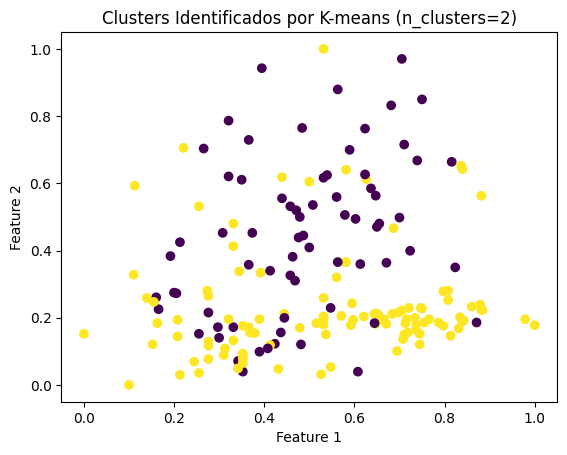

In [ ]:
# Aplicar el mejor modelo de KMeans encontrado
best_n_clusters = grid_search.best_params_['n_clusters']
best_kmeans = KMeans(n_clusters=best_n_clusters, random_state=0)
best_kmeans.fit(data_normalized)
data_normalized['Cluster'] = best_kmeans.labels_

# Visualizar los clusters resultantes
# Debido a que el dataset tiene muchas características, visualizaremos solo las dos primeras para simplificar
plt.scatter(data_normalized.iloc[:, 0], data_normalized.iloc[:, 1], c=best_kmeans.labels_, cmap='viridis', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Clusters Identificados por K-means (n_clusters={best_n_clusters})')
plt.show()

# Kfolds

In [ ]:
from sklearn.model_selection import KFold
# Evaluación con Cross-Validation
# Usaremos KFold para realizar la validación cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Evaluar el mejor modelo con validación cruzada
best_n_clusters = grid_search.best_params_['n_clusters']
best_kmeans = KMeans(n_clusters=best_n_clusters, random_state=0)

silhouette_scores = []
for train_index, test_index in kf.split(data_normalized):
    X_train, X_test = data_normalized.iloc[train_index], data_normalized.iloc[test_index]
    best_kmeans.fit(X_train)
    labels = best_kmeans.predict(X_test)
    score = silhouette_score(X_test, labels)
    silhouette_scores.append(score)

print(f"Puntuaciones de Silhouette en cada partición de la validación cruzada: {silhouette_scores}")
print(f"Puntuación promedio de Silhouette: {np.mean(silhouette_scores):.2f}")

Puntuaciones de Silhouette en cada partición de la validación cruzada: [0.46077091005250054, 0.4829194369988229, 0.44313383609898443, 0.4861843683109949, 0.47174388569575376]
Puntuación promedio de Silhouette: 0.47


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


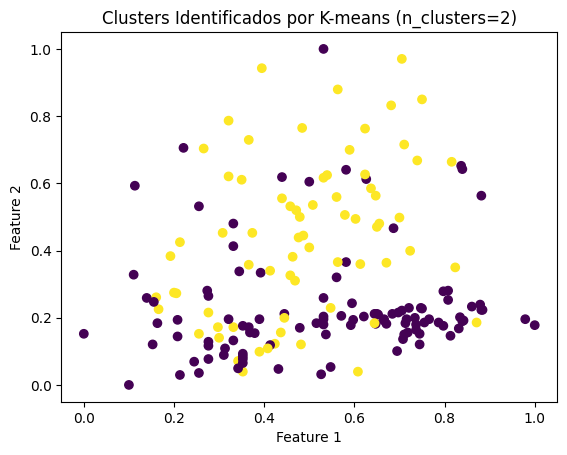

In [ ]:
# Aplicar el mejor modelo de KMeans encontrado y visualizar
best_kmeans.fit(data_normalized)
data_normalized['Cluster'] = best_kmeans.labels_

# Visualizar los clusters resultantes
# Debido a que el dataset tiene muchas características, visualizaremos solo las dos primeras para simplificar
plt.scatter(data_normalized.iloc[:, 0], data_normalized.iloc[:, 1], c=best_kmeans.labels_, cmap='viridis', marker='o')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Clusters Identificados por K-means (n_clusters={best_n_clusters})')
plt.show()